# IPL Sentiment Pipeline Selector Lab  
## Beginner-friendly vectorizer × classifier experiment notebook

This notebook helps you **choose good vectorizers and classifiers** for the IPL sentiment challenge.

You will:

1. Load the IPL sentiment dataset from GitHub.
2. Understand the columns: `statement`, `subject_keyword`, and `sentiment`.
3. Add vectorizer recipes using beginner-friendly helper functions.
4. Add classifier recipes using beginner-friendly helper functions.
5. Automatically train all vectorizer × classifier combinations.
6. Compare pipelines using accuracy, Macro F1, speed, model size, and simplicity.
7. Shortlist models for the 300-row round.
8. Select your final **4 vectorizers + 4 classifiers**.
9. Generate a JSON submission that you can copy-paste into the Django webapp.

Dataset source used by default:

`https://raw.githubusercontent.com/HimanshuKhale/ipl_sentiment/main/ipl_sentiment_small_dataset.csv`

Important: Your goal is **not** to use the heaviest model. Your goal is to choose a useful, explainable, diverse, and efficient set of pipeline components.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Submission philosophy

In this sprint, you are not only competing for accuracy.

A good submission should show:

- **Variety**: different vectorizer families and classifier families.
- **Reasoning**: why you chose each vectorizer and classifier.
- **Suitability**: simple models should be rewarded when they perform well.
- **Efficiency**: smaller/faster models are valuable.
- **Generalization**: models should work beyond one small dataset.

Bad strategy:

> Submit 4 versions of the same TF-IDF and 4 heavy classifiers.

Good strategy:

> Compare CountVectorizer, word TF-IDF, character TF-IDF, and HashingVectorizer with Naive Bayes, Logistic Regression, LinearSVC, and SGDClassifier.

In [31]:
# ============================================================
# STEP 0: Install/import libraries
# ============================================================

# !pip install pandas numpy scikit-learn matplotlib joblib

import json
import time
import os
import warnings
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
    HashingVectorizer
)

from sklearn.naive_bayes import (
    MultinomialNB,
    ComplementNB,
    BernoulliNB
)

from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
    RidgeClassifier,
    PassiveAggressiveClassifier
)

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import FunctionTransformer, Normalizer

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [32]:
# ============================================================
# STEP 1: Load the 80-row dataset from GitHub
# ============================================================

DATA_URL_80R = "/ipl_sentiment_80r.csv"

LOCAL_DATA_PATH_80R = "/ipl_sentiment_80r.csv"

def load_dataset_from_github_or_local(url, local_path):
    try:
        df = pd.read_csv(url)
        print("Loaded dataset from GitHub:", url)
        return df
    except Exception as github_error:
        print("Could not load from GitHub. Trying local file...")
        print("GitHub error:", github_error)
        if Path(local_path).exists():
            df = pd.read_csv(local_path)
            print("Loaded local dataset:", local_path)
            return df
        raise FileNotFoundError(
            "Dataset could not be loaded from GitHub or local file. "
            "Please download the CSV and put it next to this notebook."
        )

df_80 = load_dataset_from_github_or_local(DATA_URL_80R, LOCAL_DATA_PATH_80R)

print("Shape:", df_80.shape)
display(df_80.head())
print("Columns:", list(df_80.columns))

Loaded dataset from GitHub: /ipl_sentiment_80r.csv
Shape: (80, 4)


,post_id,statement,subject_keyword,sentiment
0,1,"RCB finally played like champions today, the b...",RCB,positive
1,2,RCB fans deserve better than another middle or...,RCB,negative
2,3,RCB's batting was decent but the fielding stil...,RCB,neutral
3,4,Virat's energy makes RCB matches feel electric...,RCB,positive
4,5,"RCB again lost control in the death overs, sam...",RCB,negative


Columns: ['post_id', 'statement', 'subject_keyword', 'sentiment']


In [33]:
# ============================================================
# STEP 2: Clean and standardize the dataset
# ============================================================

# Required columns:
# statement = tweet/post text
# subject_keyword = IPL team or subject
# sentiment = positive/negative/neutral

required_columns = ["statement", "subject_keyword", "sentiment"]

missing = [col for col in required_columns if col not in df_80.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Your dataset must have {required_columns}")

df_80 = df_80.dropna(subset=required_columns).copy()
df_80["statement"] = df_80["statement"].astype(str)
df_80["subject_keyword"] = df_80["subject_keyword"].astype(str)
df_80["sentiment"] = df_80["sentiment"].astype(str).str.lower().str.strip()

# Entity-aware model text:
# This helps the model learn sentiment toward the keyword, not just general sentiment.
df_80["model_text"] = df_80["subject_keyword"] + " [SEP] " + df_80["statement"]

print("Cleaned shape:", df_80.shape)
print("\nSentiment distribution:")
display(df_80["sentiment"].value_counts())

print("\nTeam/keyword distribution:")
display(df_80["subject_keyword"].value_counts())

display(df_80[["model_text", "sentiment"]].head())

Cleaned shape: (80, 5)

Sentiment distribution:


,count
sentiment,
positive,28
negative,26
neutral,26



Team/keyword distribution:


,count
subject_keyword,
RCB,8
MI,8
CSK,8
KKR,8
SRH,8
RR,8
DC,8
PBKS,8
GT,8


,model_text,sentiment
0,RCB [SEP] RCB finally played like champions to...,positive
1,RCB [SEP] RCB fans deserve better than another...,negative
2,RCB [SEP] RCB's batting was decent but the fie...,neutral
3,RCB [SEP] Virat's energy makes RCB matches fee...,positive
4,RCB [SEP] RCB again lost control in the death ...,negative


In [34]:
# ============================================================
# STEP 3: Create train/test split for the 80R experiment
# ============================================================

X = df_80["model_text"]
y = df_80["sentiment"]

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train_80))
print("Testing rows:", len(X_test_80))
print("\nTrain label distribution:")
display(y_train_80.value_counts())
print("\nTest label distribution:")
display(y_test_80.value_counts())

Training rows: 60
Testing rows: 20

Train label distribution:


,count
sentiment,
positive,21
neutral,20
negative,19



Test label distribution:


,count
sentiment,
positive,7
negative,7
neutral,6


# STEP 4: Beginner-friendly recipe system

You do **not** need to write complex registration code.

You only need to call:

```python
add_vectorizer(...)
add_classifier(...)
```

Each vectorizer/classifier becomes a **recipe**.  
The notebook will later convert recipes into real sklearn objects.

A recipe has:

- `id`: short unique name
- `name`: readable name
- `family`: category, such as `count`, `tfidf_word`, `tfidf_char`, `hashing`
- `type`: sklearn class name
- `params`: settings
- `notes`: why you chose it
- `complexity`: `low`, `medium`, or `high`

In [35]:
# ============================================================
# STEP 4A: Helper functions for adding recipes
# ============================================================

vectorizer_recipes = []
classifier_recipes = []

def add_vectorizer(id, name, family, type, params=None, notes="", complexity="low"):
    """
    Add a vectorizer recipe.

    Example:
    add_vectorizer(
        id="tfidf_word_1_2",
        name="TF-IDF Word 1-2 grams",
        family="tfidf_word",
        type="TfidfVectorizer",
        params={"ngram_range": (1, 2), "max_features": 3000},
        notes="Good baseline for short text.",
        complexity="low"
    )
    """
    if params is None:
        params = {}
    vectorizer_recipes.append({
        "id": id,
        "name": name,
        "family": family,
        "type": type,
        "params": params,
        "notes": notes,
        "complexity": complexity,
    })

def add_classifier(id, name, family, type, params=None, notes="", complexity="low"):
    """
    Add a classifier recipe.

    Example:
    add_classifier(
        id="logreg_balanced",
        name="Logistic Regression Balanced",
        family="linear",
        type="LogisticRegression",
        params={"max_iter": 1000, "class_weight": "balanced"},
        notes="Strong simple classifier for sparse text.",
        complexity="low"
    )
    """
    if params is None:
        params = {}
    classifier_recipes.append({
        "id": id,
        "name": name,
        "family": family,
        "type": type,
        "params": params,
        "notes": notes,
        "complexity": complexity,
    })

print("Helper functions are ready.")

Helper functions are ready.


In [36]:
# ============================================================
# STEP 4B: 10 vectorizers
# ============================================================

add_vectorizer(
    id="count_word",
    name="CountVectorizer Word",
    family="count",
    type="CountVectorizer",
    params={"lowercase": True, "max_features": 3000},
    notes="Simple word frequency baseline.",
    complexity="low"
)

add_vectorizer(
    id="count_binary",
    name="Binary CountVectorizer",
    family="count_binary",
    type="CountVectorizer",
    params={"lowercase": True, "binary": True, "max_features": 3000},
    notes="Tests word presence instead of frequency.",
    complexity="low"
)

add_vectorizer(
    id="count_bigram",
    name="CountVectorizer 1-2 grams",
    family="count_ngram",
    type="CountVectorizer",
    params={"lowercase": True, "ngram_range": (1, 2), "max_features": 4000},
    notes="Captures simple word frequencies and short phrases.",
    complexity="low"
)

add_vectorizer(
    id="tfidf_word",
    name="TF-IDF Word",
    family="tfidf",
    type="TfidfVectorizer",
    params={"lowercase": True, "max_features": 4000},
    notes="Weights important words more strongly.",
    complexity="low"
)

add_vectorizer(
    id="tfidf_bigram",
    name="TF-IDF 1-2 grams",
    family="tfidf_ngram",
    type="TfidfVectorizer",
    params={"lowercase": True, "ngram_range": (1, 2), "max_features": 4000},
    notes="Weights important words and short phrases.",
    complexity="low"
)

add_vectorizer(
    id="tfidf_char",
    name="Character TF-IDF",
    family="char_tfidf",
    type="TfidfVectorizer",
    params={"analyzer": "char", "ngram_range": (3, 5), "max_features": 5000},
    notes="Handles slang, typos, and repeated letters.",
    complexity="medium"
)

add_vectorizer(
    id="tfidf_char_wb",
    name="Character WB TF-IDF",
    family="char_wb_tfidf",
    type="TfidfVectorizer",
    params={"analyzer": "char_wb", "ngram_range": (3, 5), "max_features": 5000},
    notes="Character n-grams within word boundaries for noisy text.",
    complexity="medium"
)

add_vectorizer(
    id="hashing_word",
    name="HashingVectorizer Word",
    family="hashing",
    type="HashingVectorizer",
    params={"alternate_sign": False, "n_features": 2048, "lowercase": True},
    notes="Memory-efficient word hashing without storing vocabulary.",
    complexity="medium"
)

add_vectorizer(
    id="hashing_char",
    name="HashingVectorizer Character",
    family="char_hashing",
    type="HashingVectorizer",
    params={"alternate_sign": False, "n_features": 4096, "analyzer": "char", "ngram_range": (3, 5)},
    notes="Memory-efficient character-level hashing.",
    complexity="medium"
)

add_vectorizer(
    id="tfidf_svd",
    name="TF-IDF + SVD",
    family="dimensionality_reduction",
    type="TfidfSVD",
    params={},
    notes="Compresses TF-IDF into lower-dimensional features.",
    complexity="high"
)

print(f"Total vectorizers added: {len(vectorizer_recipes)}")
pd.DataFrame(vectorizer_recipes)

Total vectorizers added: 10


,id,name,family,type,params,notes,complexity
0,count_word,CountVectorizer Word,count,CountVectorizer,"{'lowercase': True, 'max_features': 3000}",Simple word frequency baseline.,low
1,count_binary,Binary CountVectorizer,count_binary,CountVectorizer,"{'lowercase': True, 'binary': True, 'max_featu...",Tests word presence instead of frequency.,low
2,count_bigram,CountVectorizer 1-2 grams,count_ngram,CountVectorizer,"{'lowercase': True, 'ngram_range': (1, 2), 'ma...",Captures simple word frequencies and short phr...,low
3,tfidf_word,TF-IDF Word,tfidf,TfidfVectorizer,"{'lowercase': True, 'max_features': 4000}",Weights important words more strongly.,low
4,tfidf_bigram,TF-IDF 1-2 grams,tfidf_ngram,TfidfVectorizer,"{'lowercase': True, 'ngram_range': (1, 2), 'ma...",Weights important words and short phrases.,low
5,tfidf_char,Character TF-IDF,char_tfidf,TfidfVectorizer,"{'analyzer': 'char', 'ngram_range': (3, 5), 'm...","Handles slang, typos, and repeated letters.",medium
6,tfidf_char_wb,Character WB TF-IDF,char_wb_tfidf,TfidfVectorizer,"{'analyzer': 'char_wb', 'ngram_range': (3, 5),...",Character n-grams within word boundaries for n...,medium
7,hashing_word,HashingVectorizer Word,hashing,HashingVectorizer,"{'alternate_sign': False, 'n_features': 2048, ...",Memory-efficient word hashing without storing ...,medium
8,hashing_char,HashingVectorizer Character,char_hashing,HashingVectorizer,"{'alternate_sign': False, 'n_features': 4096, ...",Memory-efficient character-level hashing.,medium
9,tfidf_svd,TF-IDF + SVD,dimensionality_reduction,TfidfSVD,{},Compresses TF-IDF into lower-dimensional featu...,high


In [37]:
# ============================================================
# STEP 4C: 10 classifiers
# ============================================================

add_classifier(
    id="multinomial_nb",
    name="Multinomial Naive Bayes",
    family="naive_bayes",
    type="MultinomialNB",
    params={},
    notes="Very fast probabilistic baseline for text counts.",
    complexity="low"
)

add_classifier(
    id="complement_nb",
    name="Complement Naive Bayes",
    family="naive_bayes",
    type="ComplementNB",
    params={},
    notes="Naive Bayes variant useful for imbalanced text data.",
    complexity="low"
)

add_classifier(
    id="bernoulli_nb",
    name="Bernoulli Naive Bayes",
    family="naive_bayes",
    type="BernoulliNB",
    params={},
    notes="Uses feature presence/absence logic.",
    complexity="low"
)

add_classifier(
    id="logreg_balanced",
    name="Logistic Regression Balanced",
    family="linear",
    type="LogisticRegression",
    params={"max_iter": 1000, "class_weight": "balanced", "random_state": RANDOM_STATE},
    notes="Simple explainable linear classifier.",
    complexity="low"
)

add_classifier(
    id="ridge_classifier",
    name="Ridge Classifier",
    family="linear",
    type="RidgeClassifier",
    params={},
    notes="Regularized linear classifier.",
    complexity="low"
)

add_classifier(
    id="linear_svc",
    name="LinearSVC",
    family="margin_based",
    type="LinearSVC",
    params={"random_state": RANDOM_STATE},
    notes="Strong margin-based classifier for sparse text.",
    complexity="medium"
)

add_classifier(
    id="sgd_log",
    name="SGDClassifier Logistic Loss",
    family="sgd",
    type="SGDClassifier",
    params={"loss": "log_loss", "max_iter": 1000, "random_state": RANDOM_STATE},
    notes="Scalable logistic classifier.",
    complexity="medium"
)

add_classifier(
    id="sgd_hinge",
    name="SGDClassifier Hinge Loss",
    family="sgd",
    type="SGDClassifier",
    params={"loss": "hinge", "max_iter": 1000, "random_state": RANDOM_STATE},
    notes="Scalable SVM-like classifier.",
    complexity="medium"
)

add_classifier(
    id="passive_aggressive",
    name="Passive Aggressive Classifier",
    family="online_margin",
    type="PassiveAggressiveClassifier",
    params={"max_iter": 1000, "random_state": RANDOM_STATE},
    notes="Fast online margin-based classifier.",
    complexity="medium"
)

add_classifier(
    id="random_forest_small",
    name="Small Random Forest",
    family="tree_based",
    type="RandomForestClassifier",
    params={"n_estimators": 50, "max_depth": 10, "random_state": RANDOM_STATE},
    notes="One nonlinear tree-based model for comparison.",
    complexity="high"
)

print(f"Total classifiers added: {len(classifier_recipes)}")
pd.DataFrame(classifier_recipes)

Total classifiers added: 10


,id,name,family,type,params,notes,complexity
0,multinomial_nb,Multinomial Naive Bayes,naive_bayes,MultinomialNB,{},Very fast probabilistic baseline for text counts.,low
1,complement_nb,Complement Naive Bayes,naive_bayes,ComplementNB,{},Naive Bayes variant useful for imbalanced text...,low
2,bernoulli_nb,Bernoulli Naive Bayes,naive_bayes,BernoulliNB,{},Uses feature presence/absence logic.,low
3,logreg_balanced,Logistic Regression Balanced,linear,LogisticRegression,"{'max_iter': 1000, 'class_weight': 'balanced',...",Simple explainable linear classifier.,low
4,ridge_classifier,Ridge Classifier,linear,RidgeClassifier,{},Regularized linear classifier.,low
5,linear_svc,LinearSVC,margin_based,LinearSVC,{'random_state': 42},Strong margin-based classifier for sparse text.,medium
6,sgd_log,SGDClassifier Logistic Loss,sgd,SGDClassifier,"{'loss': 'log_loss', 'max_iter': 1000, 'random...",Scalable logistic classifier.,medium
7,sgd_hinge,SGDClassifier Hinge Loss,sgd,SGDClassifier,"{'loss': 'hinge', 'max_iter': 1000, 'random_st...",Scalable SVM-like classifier.,medium
8,passive_aggressive,Passive Aggressive Classifier,online_margin,PassiveAggressiveClassifier,"{'max_iter': 1000, 'random_state': 42}",Fast online margin-based classifier.,medium
9,random_forest_small,Small Random Forest,tree_based,RandomForestClassifier,"{'n_estimators': 50, 'max_depth': 10, 'random_...",One nonlinear tree-based model for comparison.,high


In [38]:
# ============================================================
# STEP 5: Validate diversity rules
# ============================================================

def validate_recipe_diversity(vectorizers, classifiers):
    messages = []

    v_families = sorted(set(v["family"] for v in vectorizers))
    c_families = sorted(set(c["family"] for c in classifiers))
    heavy_classifiers = [c for c in classifiers if c.get("complexity") == "high"]

    messages.append(f"Vectorizer count: {len(vectorizers)}")
    messages.append(f"Classifier count: {len(classifiers)}")
    messages.append(f"Vectorizer families: {v_families}")
    messages.append(f"Classifier families: {c_families}")
    messages.append(f"Heavy classifiers: {[c['id'] for c in heavy_classifiers]}")

    warnings = []
    if len(vectorizers) < 4:
        warnings.append("Add at least 4 vectorizers before final submission.")
    if len(classifiers) < 4:
        warnings.append("Add at least 4 classifiers before final submission.")
    if len(v_families) < 3:
        warnings.append("Use at least 3 different vectorizer families.")
    if len(c_families) < 3:
        warnings.append("Use at least 3 different classifier families.")
    if len(heavy_classifiers) > 1:
        warnings.append("Use maximum 1 heavy classifier.")

    return messages, warnings

messages, warnings_list = validate_recipe_diversity(vectorizer_recipes, classifier_recipes)

print("\n".join(messages))
if warnings_list:
    print("\nWarnings:")
    for w in warnings_list:
        print("-", w)
else:
    print("\nDiversity check passed.")

Vectorizer count: 10
Classifier count: 10
Vectorizer families: ['char_hashing', 'char_tfidf', 'char_wb_tfidf', 'count', 'count_binary', 'count_ngram', 'dimensionality_reduction', 'hashing', 'tfidf', 'tfidf_ngram']
Classifier families: ['linear', 'margin_based', 'naive_bayes', 'online_margin', 'sgd', 'tree_based']
Heavy classifiers: ['random_forest_small']

Diversity check passed.


In [39]:
# ============================================================
# STEP 6: Build actual sklearn objects from recipes
# ============================================================

VECTORIZER_CLASSES = {
    "CountVectorizer": CountVectorizer,
    "TfidfVectorizer": TfidfVectorizer,
    "HashingVectorizer": HashingVectorizer,
}

CLASSIFIER_CLASSES = {
    "MultinomialNB": MultinomialNB,
    "ComplementNB": ComplementNB,
    "BernoulliNB": BernoulliNB,
    "LogisticRegression": LogisticRegression,
    "RidgeClassifier": RidgeClassifier,
    "LinearSVC": LinearSVC,
    "SGDClassifier": SGDClassifier,
    "PassiveAggressiveClassifier": PassiveAggressiveClassifier,
    "RandomForestClassifier": RandomForestClassifier,
}

def clean_params(params):
    params = deepcopy(params)
    if "ngram_range" in params and isinstance(params["ngram_range"], list):
        params["ngram_range"] = tuple(params["ngram_range"])
    return params

def build_vectorizer(recipe):
    if recipe["type"] == "TfidfSVD":
        return Pipeline([
            ("tfidf", TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                max_features=5000
            )),
            ("svd", TruncatedSVD(n_components=20, random_state=RANDOM_STATE)),
            ("abs", FunctionTransformer(lambda X: np.abs(X))),
            ("norm", Normalizer())
        ])

    cls = VECTORIZER_CLASSES[recipe["type"]]
    return cls(**clean_params(recipe.get("params", {})))

def build_classifier(recipe):
    cls = CLASSIFIER_CLASSES[recipe["type"]]
    return cls(**clean_params(recipe.get("params", {})))

def make_pipeline(vectorizer_recipe, classifier_recipe):
    return Pipeline([
        ("vectorizer", build_vectorizer(vectorizer_recipe)),
        ("classifier", build_classifier(classifier_recipe)),
    ])

print("Factory functions are ready.")

Factory functions are ready.


In [40]:
# ============================================================
# STEP 7: Train every vectorizer × classifier combination on 80R
# ============================================================

def estimate_model_size_kb(model, temp_path="temp_pipeline_model.joblib"):
    try:
        joblib.dump(model, temp_path)
        size_kb = os.path.getsize(temp_path) / 1024
        os.remove(temp_path)
        return size_kb
    except Exception:
        return np.nan

def complexity_penalty(v_recipe, c_recipe):
    # Higher complexity gets a small penalty in suitability score.
    levels = {"low": 0, "medium": 1, "high": 2}
    return levels.get(v_recipe.get("complexity", "low"), 0) + levels.get(c_recipe.get("complexity", "low"), 0)

def run_single_pipeline(v_recipe, c_recipe, X_train, X_test, y_train, y_test):
    result = {
        "vectorizer_id": v_recipe["id"],
        "vectorizer_name": v_recipe["name"],
        "vectorizer_family": v_recipe["family"],
        "vectorizer_complexity": v_recipe.get("complexity", "low"),
        "classifier_id": c_recipe["id"],
        "classifier_name": c_recipe["name"],
        "classifier_family": c_recipe["family"],
        "classifier_complexity": c_recipe.get("complexity", "low"),
        "pipeline_id": f"{v_recipe['id']}__{c_recipe['id']}",
    }

    try:
        pipeline = make_pipeline(v_recipe, c_recipe)

        start_train = time.time()
        pipeline.fit(X_train, y_train)
        train_time = time.time() - start_train

        start_pred = time.time()
        y_pred = pipeline.predict(X_test)
        pred_time = time.time() - start_pred

        acc = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
        size_kb = estimate_model_size_kb(pipeline)

        # Simple scoring:
        # Performance is important, but efficient/simple models get rewarded too.
        performance_score = (macro_f1 * 60) + (acc * 25) + (weighted_f1 * 15)

        # Efficiency score rewards fast/small models.
        speed_score = max(0, 100 - (train_time * 10) - (pred_time * 100))
        size_score = max(0, 100 - (size_kb / 20)) if not np.isnan(size_kb) else 50
        efficiency_score = (speed_score * 0.6) + (size_score * 0.4)

        # Suitability rewards simpler models unless heavy models strongly outperform.
        penalty = complexity_penalty(v_recipe, c_recipe)
        suitability_score = max(0, 100 - penalty * 15)

        final_score = (
            performance_score * 0.55
            + efficiency_score * 0.20
            + suitability_score * 0.15
            + 100 * 0.10  # basic completion score
        )

        result.update({
            "status": "completed",
            "accuracy": acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "train_time_sec": train_time,
            "prediction_time_sec": pred_time,
            "model_size_kb": size_kb,
            "performance_score": performance_score,
            "efficiency_score": efficiency_score,
            "suitability_score": suitability_score,
            "final_score": final_score,
            "error": "",
        })

    except Exception as e:
        result.update({
            "status": "failed",
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
            "precision_macro": np.nan,
            "recall_macro": np.nan,
            "train_time_sec": np.nan,
            "prediction_time_sec": np.nan,
            "model_size_kb": np.nan,
            "performance_score": 0,
            "efficiency_score": 0,
            "suitability_score": 0,
            "final_score": 0,
            "error": str(e),
        })

    return result

all_results = []
total_runs = len(vectorizer_recipes) * len(classifier_recipes)
print(f"Running {total_runs} pipelines...")

for v in vectorizer_recipes:
    for c in classifier_recipes:
        print(f"Training: {v['id']} + {c['id']}")
        result = run_single_pipeline(v, c, X_train_80, X_test_80, y_train_80, y_test_80)
        all_results.append(result)

results_80 = pd.DataFrame(all_results).sort_values("final_score", ascending=False).reset_index(drop=True)
results_80.insert(0, "rank", range(1, len(results_80) + 1))

print("Done.")
display(results_80)

Running 100 pipelines...
Training: count_word + multinomial_nb
Training: count_word + complement_nb
Training: count_word + bernoulli_nb
Training: count_word + logreg_balanced
Training: count_word + ridge_classifier
Training: count_word + linear_svc
Training: count_word + sgd_log
Training: count_word + sgd_hinge
Training: count_word + passive_aggressive
Training: count_word + random_forest_small
Training: count_binary + multinomial_nb
Training: count_binary + complement_nb
Training: count_binary + bernoulli_nb
Training: count_binary + logreg_balanced
Training: count_binary + ridge_classifier
Training: count_binary + linear_svc
Training: count_binary + sgd_log
Training: count_binary + sgd_hinge
Training: count_binary + passive_aggressive
Training: count_binary + random_forest_small
Training: count_bigram + multinomial_nb
Training: count_bigram + complement_nb
Training: count_bigram + bernoulli_nb
Training: count_bigram + logreg_balanced
Training: count_bigram + ridge_classifier
Training:

,rank,vectorizer_id,vectorizer_name,vectorizer_family,vectorizer_complexity,classifier_id,classifier_name,classifier_family,classifier_complexity,pipeline_id,...,precision_macro,recall_macro,train_time_sec,prediction_time_sec,model_size_kb,performance_score,efficiency_score,suitability_score,final_score,error
0,1,count_binary,Binary CountVectorizer,count_binary,low,ridge_classifier,Ridge Classifier,linear,low,count_binary__ridge_classifier,...,0.783333,0.761905,0.011777,0.001253,16.567383,74.846257,99.522790,100,86.069999,
1,2,count_binary,Binary CountVectorizer,count_binary,low,complement_nb,Complement Naive Bayes,naive_bayes,low,count_binary__complement_nb,...,0.694048,0.714286,0.003385,0.000800,25.864258,69.573718,99.414428,100,83.148430,
2,3,count_word,CountVectorizer Word,count,low,complement_nb,Complement Naive Bayes,naive_bayes,low,count_word__complement_nb,...,0.688095,0.714286,0.006311,0.001237,25.864258,69.160714,99.370604,100,82.912514,
3,4,count_binary,Binary CountVectorizer,count_binary,low,linear_svc,LinearSVC,margin_based,medium,count_binary__linear_svc,...,0.737374,0.714286,0.005405,0.001129,16.511719,68.933333,99.569616,85,80.577256,
4,5,count_binary,Binary CountVectorizer,count_binary,low,logreg_balanced,Logistic Regression Balanced,linear,low,count_binary__logreg_balanced,...,0.666667,0.666667,0.012081,0.001216,16.687500,64.784759,99.520791,100,80.535776,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,tfidf_svd,TF-IDF + SVD,dimensionality_reduction,high,random_forest_small,Small Random Forest,tree_based,high,tfidf_svd__random_forest_small,...,0.301515,0.341270,0.199436,0.006065,NaN,31.823232,78.439505,40,49.190679,
96,97,tfidf_svd,TF-IDF + SVD,dimensionality_reduction,high,bernoulli_nb,Bernoulli Naive Bayes,naive_bayes,low,tfidf_svd__bernoulli_nb,...,0.116667,0.333333,0.040109,0.003606,NaN,21.842593,79.542996,70,48.422025,
97,98,tfidf_svd,TF-IDF + SVD,dimensionality_reduction,high,passive_aggressive,Passive Aggressive Classifier,online_margin,medium,tfidf_svd__passive_aggressive,...,0.197802,0.317460,0.022529,0.003412,NaN,25.030075,79.660075,55,47.948556,
98,99,tfidf_svd,TF-IDF + SVD,dimensionality_reduction,high,sgd_hinge,SGDClassifier Hinge Loss,sgd,medium,tfidf_svd__sgd_hinge,...,0.197802,0.317460,0.022665,0.003417,NaN,25.030075,79.659016,55,47.948345,


In [41]:
results_80.groupby("classifier_id")[["accuracy","macro_f1","final_score"]].mean().sort_values("final_score", ascending=False)

,accuracy,macro_f1,final_score
classifier_id,,,
random_forest_small,0.660,0.639809,73.264246
ridge_classifier,0.540,0.536853,72.371438
bernoulli_nb,0.565,0.502989,71.168824
logreg_balanced,0.510,0.504575,70.618629
linear_svc,0.535,0.527245,69.667541
complement_nb,0.485,0.462937,68.398815
multinomial_nb,0.470,0.443283,67.436019
sgd_log,0.490,0.471461,66.738972
passive_aggressive,0.470,0.453115,65.720282


In [42]:
# ============================================================
# STEP 8: Save and inspect 80R results
# ============================================================

results_80.to_csv("results_80R.csv", index=False)
print("Saved: results_80R.csv")

print("\nTop 10 pipelines by final_score:")
display(results_80.head(10)[[
    "rank",
    "pipeline_id",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "train_time_sec",
    "model_size_kb",
    "final_score",
    "status",
]])

print("\nFailed pipelines, if any:")
display(results_80[results_80["status"] == "failed"][["pipeline_id", "error"]])

Saved: results_80R.csv

Top 10 pipelines by final_score:


,rank,pipeline_id,accuracy,macro_f1,weighted_f1,train_time_sec,model_size_kb,final_score,status
0,1,count_binary__ridge_classifier,0.75,0.750446,0.737968,0.011777,16.567383,86.069999,completed
1,2,count_binary__complement_nb,0.70,0.696581,0.685256,0.003385,25.864258,83.148430,completed
2,3,count_word__complement_nb,0.70,0.690476,0.682143,0.006311,25.864258,82.912514,completed
3,4,count_binary__linear_svc,0.70,0.688889,0.673333,0.005405,16.511719,80.577256,completed
4,5,count_binary__logreg_balanced,0.65,0.650624,0.633155,0.012081,16.687500,80.535776,completed
5,6,count_word__logreg_balanced,0.65,0.650624,0.633155,0.012775,16.687500,80.534975,completed
6,7,count_binary__multinomial_nb,0.65,0.642857,0.632143,0.004332,23.458008,80.257087,completed
7,8,count_word__random_forest_small,0.75,0.727096,0.713450,0.089113,161.452148,79.885518,completed
8,9,tfidf_bigram__random_forest_small,0.75,0.715100,0.704701,0.085086,160.543945,79.417866,completed
9,10,count_binary__bernoulli_nb,0.65,0.603989,0.588034,0.004178,23.473633,78.606515,completed



Failed pipelines, if any:


,pipeline_id,error


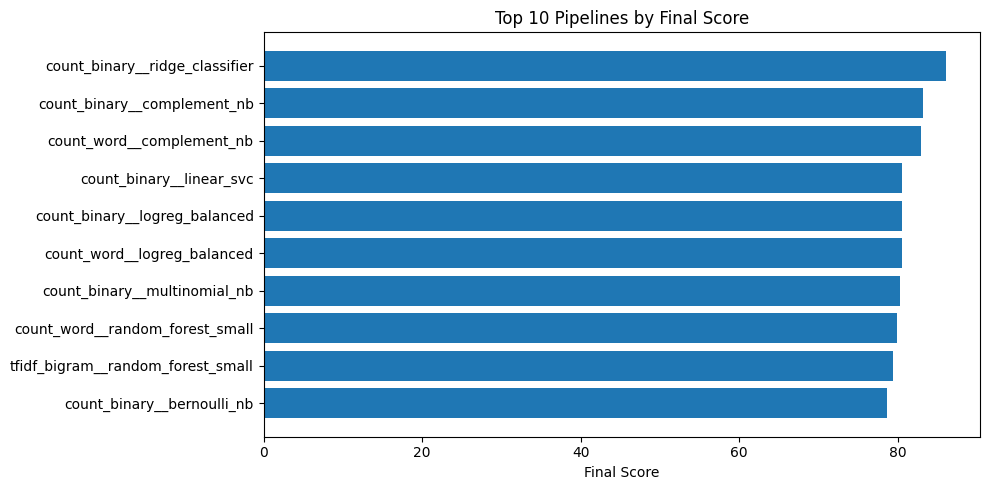

Average performance by vectorizer family:


,macro_f1,accuracy,final_score
vectorizer_family,,,
count_binary,0.650189,0.670,79.388764
count,0.615101,0.630,77.392498
tfidf,0.563238,0.570,74.413963
hashing,0.560694,0.585,72.106651
count_ngram,0.504280,0.515,71.151905
char_hashing,0.526405,0.570,70.266103
char_tfidf,0.450122,0.470,64.980942
char_wb_tfidf,0.444527,0.455,64.932876
tfidf_ngram,0.380300,0.390,64.359400


Average performance by classifier family:


,macro_f1,accuracy,final_score
classifier_family,,,
tree_based,0.639809,0.660000,73.264246
linear,0.520714,0.525000,71.495034
margin_based,0.527245,0.535000,69.667541
naive_bayes,0.469736,0.506667,69.001219
sgd,0.458318,0.482500,66.107408
online_margin,0.453115,0.470000,65.720282


In [43]:
# ============================================================
# STEP 9: Visual analytics
# ============================================================

completed = results_80[results_80["status"] == "completed"].copy()

if completed.empty:
    print("No completed models to visualize.")
else:
    top_plot = completed.sort_values("final_score", ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    plt.barh(top_plot["pipeline_id"][::-1], top_plot["final_score"][::-1])
    plt.xlabel("Final Score")
    plt.title("Top 10 Pipelines by Final Score")
    plt.tight_layout()
    plt.show()

    family_perf = completed.groupby("vectorizer_family")[["macro_f1", "accuracy", "final_score"]].mean().sort_values("final_score", ascending=False)
    print("Average performance by vectorizer family:")
    display(family_perf)

    clf_perf = completed.groupby("classifier_family")[["macro_f1", "accuracy", "final_score"]].mean().sort_values("final_score", ascending=False)
    print("Average performance by classifier family:")
    display(clf_perf)

# STEP 10: Understand one selected pipeline

Use this section to inspect the confusion matrix and classification report of a pipeline.

By default, it chooses the top-ranked pipeline.  
You can change `SELECTED_PIPELINE_ID` to any pipeline from `results_80`.

In [44]:
# ============================================================
# STEP 10A: Detailed report for one pipeline
# ============================================================

SELECTED_PIPELINE_ID = results_80.iloc[0]["pipeline_id"]  # change this if needed

selected_row = results_80[results_80["pipeline_id"] == SELECTED_PIPELINE_ID].iloc[0]
v_recipe = next(v for v in vectorizer_recipes if v["id"] == selected_row["vectorizer_id"])
c_recipe = next(c for c in classifier_recipes if c["id"] == selected_row["classifier_id"])

pipeline = make_pipeline(v_recipe, c_recipe)
pipeline.fit(X_train_80, y_train_80)
y_pred = pipeline.predict(X_test_80)

print("Selected pipeline:", SELECTED_PIPELINE_ID)
print("\nClassification report:")
print(classification_report(y_test_80, y_pred, zero_division=0))

labels = sorted(y.unique())
cm = confusion_matrix(y_test_80, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"actual_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])
display(cm_df)

Selected pipeline: count_binary__ridge_classifier

Classification report:
              precision    recall  f1-score   support

    negative       0.75      0.43      0.55         7
     neutral       1.00      1.00      1.00         6
    positive       0.60      0.86      0.71         7

    accuracy                           0.75        20
   macro avg       0.78      0.76      0.75        20
weighted avg       0.77      0.75      0.74        20



,pred_negative,pred_neutral,pred_positive
actual_negative,3,0,4
actual_neutral,0,6,0
actual_positive,1,0,6


# STEP 11: Shortlist candidates for the 300R round

The notebook will suggest candidates using two ideas:

1. Top pipelines by score.
2. Best representative from each vectorizer/classifier family.

This helps avoid the mistake of selecting only one type of model.

In [45]:
# ============================================================
# STEP 11A: Candidate shortlist
# ============================================================

def make_candidate_shortlist(results_df, top_n=8):
    completed = results_df[results_df["status"] == "completed"].copy()
    if completed.empty:
        return completed

    top_overall = completed.sort_values("final_score", ascending=False).head(top_n)

    best_by_vectorizer_family = (
        completed.sort_values("final_score", ascending=False)
        .groupby("vectorizer_family")
        .head(1)
    )

    best_by_classifier_family = (
        completed.sort_values("final_score", ascending=False)
        .groupby("classifier_family")
        .head(1)
    )

    shortlist = pd.concat([top_overall, best_by_vectorizer_family, best_by_classifier_family])
    shortlist = shortlist.drop_duplicates(subset=["pipeline_id"])
    shortlist = shortlist.sort_values("final_score", ascending=False).reset_index(drop=True)
    shortlist.insert(0, "candidate_rank", range(1, len(shortlist) + 1))
    return shortlist

candidate_shortlist = make_candidate_shortlist(results_80, top_n=8)

print("Candidate shortlist for 300R round:")
display(candidate_shortlist[[
    "candidate_rank",
    "pipeline_id",
    "vectorizer_family",
    "classifier_family",
    "accuracy",
    "macro_f1",
    "final_score"
]])

Candidate shortlist for 300R round:


,candidate_rank,pipeline_id,vectorizer_family,classifier_family,accuracy,macro_f1,final_score
0,1,count_binary__ridge_classifier,count_binary,linear,0.75,0.750446,86.069999
1,2,count_binary__complement_nb,count_binary,naive_bayes,0.70,0.696581,83.148430
2,3,count_word__complement_nb,count,naive_bayes,0.70,0.690476,82.912514
3,4,count_binary__linear_svc,count_binary,margin_based,0.70,0.688889,80.577256
4,5,count_binary__logreg_balanced,count_binary,linear,0.65,0.650624,80.535776
5,6,count_word__logreg_balanced,count,linear,0.65,0.650624,80.534975
6,7,count_binary__multinomial_nb,count_binary,naive_bayes,0.65,0.642857,80.257087
7,8,count_word__random_forest_small,count,tree_based,0.75,0.727096,79.885518
8,9,tfidf_bigram__random_forest_small,tfidf_ngram,tree_based,0.75,0.715100,79.417866
9,10,tfidf_word__bernoulli_nb,tfidf,naive_bayes,0.65,0.603989,78.590214


# STEP 12: Optional 300R round

Use this only after you have a 300-row dataset.

The notebook tries these options:

1. If you upload or place `ipl_300R_indian_english_sentiment_dataset.csv` next to the notebook, it will load it.
2. If you put the 300R dataset in GitHub later, paste the raw GitHub URL into `DATA_URL_300R`.
3. If you do not have 300R yet, skip this section.

Expected 300R columns can be either:

- `tweet`, `subject_keyword`, `sentiment`
- or `statement`, `subject_keyword`, `sentiment`

If the column is `tweet`, the notebook renames it to `statement`.

In [55]:
# ============================================================
# STEP 12A: Load optional 300R dataset
# ============================================================

DATA_URL_300R = "/ipl_sentiment_300r.csv"
LOCAL_DATA_PATH_300R = "/ipl_sentiment_300r.csv"

def load_optional_300R():
    if DATA_URL_300R:
        try:
            df = pd.read_csv(DATA_URL_300R)
            print("Loaded 300R from GitHub:", DATA_URL_300R)
            return df
        except Exception as e:
            print("Could not load DATA_URL_300R:", e)

    if Path(LOCAL_DATA_PATH_300R).exists():
        df = pd.read_csv(LOCAL_DATA_PATH_300R)
        print("Loaded local 300R dataset:", LOCAL_DATA_PATH_300R)
        return df

    print("No 300R dataset found. You can skip the 300R section for now.")
    return None

df_300 = load_optional_300R()

if df_300 is not None:
    if "tweet" in df_300.columns and "statement" not in df_300.columns:
        df_300 = df_300.rename(columns={"tweet": "statement"})

    missing = [col for col in required_columns if col not in df_300.columns]
    if missing:
        raise ValueError(f"300R dataset is missing required columns: {missing}")

    df_300 = df_300.dropna(subset=required_columns).copy()
    df_300["statement"] = df_300["statement"].astype(str)
    df_300["subject_keyword"] = df_300["subject_keyword"].astype(str)
    df_300["sentiment"] = df_300["sentiment"].astype(str).str.lower().str.strip()
    df_300["model_text"] = df_300["subject_keyword"] + " [SEP] " + df_300["statement"]

    print("300R shape:", df_300.shape)
    display(df_300.head())
    display(df_300["sentiment"].value_counts())

Loaded 300R from GitHub: /ipl_sentiment_300r.csv
300R shape: (300, 5)


,post_id,statement,subject_keyword,sentiment,model_text
0,IPL300R_042,tbh honestly mi bowling was all over the place...,MI,negative,MI [SEP] tbh honestly mi bowling was all over ...
1,IPL300R_197,"ngl bro dc bowling without plan lag rhi thi, ...",DC,negative,DC [SEP] ngl bro dc bowling without plan lag ...
2,IPL300R_109,"ngl bro KKR bowling without plan lag rhi thi, ...",KKR,negative,KKR [SEP] ngl bro KKR bowling without plan lag...
3,IPL300R_119,"dekho KKR ka match dekha, few good moments but...",KKR,neutral,"KKR [SEP] dekho KKR ka match dekha, few good m..."
4,IPL300R_034,bhai MI finally playing like a proper champion...,MI,positive,MI [SEP] bhai MI finally playing like a proper...


,count
sentiment,
negative,100
neutral,100
positive,100


In [56]:
# ============================================================
# STEP 12B: Run 6x6 shortlisted pipelines on 300R
# ============================================================

if df_300 is None:
    print("Skipping 300R experiment because no 300R dataset was loaded.")
    results_300 = pd.DataFrame()

else:
    X_300 = df_300["model_text"]
    y_300 = df_300["sentiment"]

    X_train_300, X_test_300, y_train_300, y_test_300 = train_test_split(
        X_300,
        y_300,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_300
    )

    # -------------------------
    # Best 6 vectorizers
    # -------------------------
    selected_vectorizer_ids_for_300R = [
        "count_binary",
        "count_word",
        "tfidf_word",
        "hashing_word",
        "count_bigram",
        "hashing_char"
    ]

    # -------------------------
    # Best 6 classifiers
    # -------------------------
    selected_classifier_ids_for_300R = [
        "ridge_classifier",
        "complement_nb",
        "bernoulli_nb",
        "logreg_balanced",
        "linear_svc",
        "random_forest_small"
    ]

    results_300_list = []

    total_runs = (
        len(selected_vectorizer_ids_for_300R)
        * len(selected_classifier_ids_for_300R)
    )

    print(f"Running {total_runs} pipelines on 300R...")

    for v_id in selected_vectorizer_ids_for_300R:

        v_recipe = next(
            v for v in vectorizer_recipes
            if v["id"] == v_id
        )

        for c_id in selected_classifier_ids_for_300R:

            c_recipe = next(
                c for c in classifier_recipes
                if c["id"] == c_id
            )

            print(f"300R training: {v_id} + {c_id}")

            result = run_single_pipeline(
                v_recipe,
                c_recipe,
                X_train_300,
                X_test_300,
                y_train_300,
                y_test_300
            )

            results_300_list.append(result)

    results_300 = (
        pd.DataFrame(results_300_list)
        .sort_values("final_score", ascending=False)
        .reset_index(drop=True)
    )

    results_300.insert(
        0,
        "rank_300R",
        range(1, len(results_300) + 1)
    )

    results_300.to_csv("results_300R.csv", index=False)

    print("Saved: results_300R.csv")
    display(results_300)

Running 36 pipelines on 300R...
300R training: count_binary + ridge_classifier
300R training: count_binary + complement_nb
300R training: count_binary + bernoulli_nb
300R training: count_binary + logreg_balanced
300R training: count_binary + linear_svc
300R training: count_binary + random_forest_small
300R training: count_word + ridge_classifier
300R training: count_word + complement_nb
300R training: count_word + bernoulli_nb
300R training: count_word + logreg_balanced
300R training: count_word + linear_svc
300R training: count_word + random_forest_small
300R training: tfidf_word + ridge_classifier
300R training: tfidf_word + complement_nb
300R training: tfidf_word + bernoulli_nb
300R training: tfidf_word + logreg_balanced
300R training: tfidf_word + linear_svc
300R training: tfidf_word + random_forest_small
300R training: hashing_word + ridge_classifier
300R training: hashing_word + complement_nb
300R training: hashing_word + bernoulli_nb
300R training: hashing_word + logreg_balanced

,rank_300R,vectorizer_id,vectorizer_name,vectorizer_family,vectorizer_complexity,classifier_id,classifier_name,classifier_family,classifier_complexity,pipeline_id,...,precision_macro,recall_macro,train_time_sec,prediction_time_sec,model_size_kb,performance_score,efficiency_score,suitability_score,final_score,error
0,1,count_word,CountVectorizer Word,count,low,ridge_classifier,Ridge Classifier,linear,low,count_word__ridge_classifier,...,1.000000,1.000000,0.016311,0.001731,16.004883,100.000000,99.478183,100,99.895637,
1,2,count_binary,Binary CountVectorizer,count_binary,low,ridge_classifier,Ridge Classifier,linear,low,count_binary__ridge_classifier,...,1.000000,1.000000,0.017329,0.001784,16.004883,100.000000,99.468869,100,99.893774,
2,3,tfidf_word,TF-IDF Word,tfidf,low,ridge_classifier,Ridge Classifier,linear,low,tfidf_word__ridge_classifier,...,1.000000,1.000000,0.012242,0.002141,18.368164,100.000000,99.430756,100,99.886151,
3,4,count_binary,Binary CountVectorizer,count_binary,low,logreg_balanced,Logistic Regression Balanced,linear,low,count_binary__logreg_balanced,...,1.000000,1.000000,0.016293,0.002597,16.125000,100.000000,99.423919,100,99.884784,
4,5,count_word,CountVectorizer Word,count,low,logreg_balanced,Logistic Regression Balanced,linear,low,count_word__logreg_balanced,...,1.000000,1.000000,0.017164,0.002872,16.125000,100.000000,99.402167,100,99.880433,
5,6,count_word,CountVectorizer Word,count,low,complement_nb,Complement Naive Bayes,naive_bayes,low,count_word__complement_nb,...,1.000000,1.000000,0.005749,0.001569,25.129883,100.000000,99.368754,100,99.873751,
6,7,count_binary,Binary CountVectorizer,count_binary,low,complement_nb,Complement Naive Bayes,naive_bayes,low,count_binary__complement_nb,...,1.000000,1.000000,0.006605,0.001650,25.129883,100.000000,99.358779,100,99.871756,
7,8,tfidf_word,TF-IDF Word,tfidf,low,logreg_balanced,Logistic Regression Balanced,linear,low,tfidf_word__logreg_balanced,...,1.000000,1.000000,0.016170,0.003208,18.457031,100.000000,99.341381,100,99.868276,
8,9,tfidf_word,TF-IDF Word,tfidf,low,complement_nb,Complement Naive Bayes,naive_bayes,low,tfidf_word__complement_nb,...,1.000000,1.000000,0.006868,0.002124,27.415039,100.000000,99.283059,100,99.856612,
9,10,count_bigram,CountVectorizer 1-2 grams,count_ngram,low,ridge_classifier,Ridge Classifier,linear,low,count_bigram__ridge_classifier,...,1.000000,1.000000,0.058752,0.005864,66.895508,100.000000,97.957717,100,99.591543,


# STEP 13: Select final 4 vectorizers and 4 classifiers

This is the most important submission step.

Rules:

- Select exactly **4 vectorizers**.
- Select exactly **4 classifiers**.
- Vectorizers should come from at least **3 different families**.
- Classifiers should come from at least **3 different families**.
- Maximum **1 heavy classifier**.
- Do not select duplicates or near-duplicates.
- Include at least one simple baseline.

Edit the lists below after reviewing your 80R and 300R results.

In [48]:
# ============================================================
# STEP 13A: Final selection
# ============================================================

print("Available vectorizers:")
display(pd.DataFrame(vectorizer_recipes)[["id", "name", "family", "complexity", "notes"]])

print("Available classifiers:")
display(pd.DataFrame(classifier_recipes)[["id", "name", "family", "complexity", "notes"]])

# Default good beginner selection:
FINAL_VECTORIZER_IDS = [
    "count_binary",
    "tfidf_word",
    "hashing_word",
    "count_bigram",
]

FINAL_CLASSIFIER_IDS = [
    "ridge_classifier",
    "complement_nb",
    "logreg_balanced",
    "linear_svc",
]

final_vectorizers = [v for v in vectorizer_recipes if v["id"] in FINAL_VECTORIZER_IDS]
final_classifiers = [c for c in classifier_recipes if c["id"] in FINAL_CLASSIFIER_IDS]

print("Selected vectorizers:", [v["id"] for v in final_vectorizers])
print("Selected classifiers:", [c["id"] for c in final_classifiers])

messages, warnings_list = validate_recipe_diversity(final_vectorizers, final_classifiers)
print("\n".join(messages))
if warnings_list:
    print("\nWarnings:")
    for w in warnings_list:
        print("-", w)
else:
    print("\nFinal diversity check passed.")

Available vectorizers:


,id,name,family,complexity,notes
0,count_word,CountVectorizer Word,count,low,Simple word frequency baseline.
1,count_binary,Binary CountVectorizer,count_binary,low,Tests word presence instead of frequency.
2,count_bigram,CountVectorizer 1-2 grams,count_ngram,low,Captures simple word frequencies and short phr...
3,tfidf_word,TF-IDF Word,tfidf,low,Weights important words more strongly.
4,tfidf_bigram,TF-IDF 1-2 grams,tfidf_ngram,low,Weights important words and short phrases.
5,tfidf_char,Character TF-IDF,char_tfidf,medium,"Handles slang, typos, and repeated letters."
6,tfidf_char_wb,Character WB TF-IDF,char_wb_tfidf,medium,Character n-grams within word boundaries for n...
7,hashing_word,HashingVectorizer Word,hashing,medium,Memory-efficient word hashing without storing ...
8,hashing_char,HashingVectorizer Character,char_hashing,medium,Memory-efficient character-level hashing.
9,tfidf_svd,TF-IDF + SVD,dimensionality_reduction,high,Compresses TF-IDF into lower-dimensional featu...


Available classifiers:


,id,name,family,complexity,notes
0,multinomial_nb,Multinomial Naive Bayes,naive_bayes,low,Very fast probabilistic baseline for text counts.
1,complement_nb,Complement Naive Bayes,naive_bayes,low,Naive Bayes variant useful for imbalanced text...
2,bernoulli_nb,Bernoulli Naive Bayes,naive_bayes,low,Uses feature presence/absence logic.
3,logreg_balanced,Logistic Regression Balanced,linear,low,Simple explainable linear classifier.
4,ridge_classifier,Ridge Classifier,linear,low,Regularized linear classifier.
5,linear_svc,LinearSVC,margin_based,medium,Strong margin-based classifier for sparse text.
6,sgd_log,SGDClassifier Logistic Loss,sgd,medium,Scalable logistic classifier.
7,sgd_hinge,SGDClassifier Hinge Loss,sgd,medium,Scalable SVM-like classifier.
8,passive_aggressive,Passive Aggressive Classifier,online_margin,medium,Fast online margin-based classifier.
9,random_forest_small,Small Random Forest,tree_based,high,One nonlinear tree-based model for comparison.


Selected vectorizers: ['count_binary', 'count_bigram', 'tfidf_word', 'hashing_word']
Selected classifiers: ['complement_nb', 'logreg_balanced', 'ridge_classifier', 'linear_svc']
Vectorizer count: 4
Classifier count: 4
Vectorizer families: ['count_binary', 'count_ngram', 'hashing', 'tfidf']
Classifier families: ['linear', 'margin_based', 'naive_bayes']
Heavy classifiers: []

Final diversity check passed.


In [49]:
# ============================================================
# STEP 14: Generate JSON submission manifest
# ============================================================

def json_safe(obj):
    # Convert tuples and numpy values to JSON-safe types.
    if isinstance(obj, tuple):
        return list(obj)
    if isinstance(obj, dict):
        return {k: json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_safe(x) for x in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

STUDENT_NAME = "AAHAN LULLA"
TEAM_NAME = "N/A"

# Explain your research thinking in 3-5 lines.
STUDENT_HYPOTHESIS = (
    "I compared diverse vectorization approaches including binary count, TF-IDF, "
    "hashing, and n-gram representations to study frequency-based, importance-based, "
    "and scalable text representations. I compared probabilistic, linear, and "
    "margin-based classifiers while prioritizing accuracy, simplicity, efficiency, "
    "generalization, and model diversity. Final selections were based on performance across both datasets while avoiding over-complex models and near-duplicate choices."
)

best_80_pipeline = results_80.iloc[0].to_dict()

if "results_300" in globals() and isinstance(results_300, pd.DataFrame) and not results_300.empty:
    best_300_pipeline = results_300.iloc[0].to_dict()
else:
    best_300_pipeline = None

submission_manifest = {
    "student_name": STUDENT_NAME,
    "team_name": TEAM_NAME,
    "task_type": "entity_aware_sentiment_classification",
    "dataset_used_for_initial_experiment": "/content/ipl_sentiment_analysis.csv",
    "target_labels": sorted(df_80["sentiment"].unique().tolist()),
    "model_input_format": "subject_keyword + ' [SEP] ' + statement",
    "hypothesis": STUDENT_HYPOTHESIS,
    "final_vectorizers": json_safe(final_vectorizers),
    "final_classifiers": json_safe(final_classifiers),
    "best_80R_pipeline": json_safe(best_80_pipeline),
    "best_300R_pipeline": json_safe(best_300_pipeline),
    "files_expected": [
        "completed_notebook.ipynb",
        "submission_manifest.json",
        "results_80R.csv",
        "results_300R.csv if 300R was used"
    ],
}

print(json.dumps(submission_manifest, indent=2))

with open("submission_manifest.json", "w", encoding="utf-8") as f:
    json.dump(submission_manifest, f, indent=2)

print("\nSaved: submission_manifest.json")

{
  "student_name": "AAHAN LULLA",
  "team_name": "N/A",
  "task_type": "entity_aware_sentiment_classification",
  "dataset_used_for_initial_experiment": "/content/ipl_sentiment_analysis.csv",
  "target_labels": [
    "negative",
    "neutral",
    "positive"
  ],
  "model_input_format": "subject_keyword + ' [SEP] ' + statement",
  "hypothesis": "I compared diverse vectorization approaches including binary count, TF-IDF, hashing, and n-gram representations to study frequency-based, importance-based, and scalable text representations. I compared probabilistic, linear, and margin-based classifiers while prioritizing accuracy, simplicity, efficiency, generalization, and model diversity. Final selections were based on performance across both datasets while avoiding over-complex models and near-duplicate choices.",
  "final_vectorizers": [
    {
      "id": "count_binary",
      "name": "Binary CountVectorizer",
      "family": "count_binary",
      "type": "CountVectorizer",
      "params"

# STEP 15: Final checklist before submission

Submit these files:

1. Your completed notebook: `.ipynb`
2. `submission_manifest.json`
3. `results_80R.csv`
4. `results_300R.csv` if you used the 300-row dataset

Your final JSON must contain exactly:

- 4 vectorizers
- 4 classifiers

Before submitting, check:

- Did you write your name and team name?
- Did your notebook run from top to bottom?
- Did you avoid near-duplicate choices?
- Did you include at least 3 vectorizer families?
- Did you include at least 3 classifier families?
- Did you explain why you chose the final 4+4?
- Did you avoid using many heavy models?
- Did your model input include the subject keyword?

Remember: a simple, explainable, fast model with decent performance can score better than a heavy model with only slightly higher accuracy.

In [50]:
import os
print(os.listdir())

['.config', 'submission_manifest.json', 'temp_pipeline_model.joblib', 'results_80R.csv', 'drive', 'sample_data']


In [52]:
# ============================================================
# OPTIONAL: Save your best 80R pipeline as a demo pkl
# ============================================================

SAVE_DEMO_BEST_PIPELINE = False

if SAVE_DEMO_BEST_PIPELINE:
    best_row = results_80.iloc[0]
    v_recipe = next(v for v in vectorizer_recipes if v["id"] == best_row["vectorizer_id"])
    c_recipe = next(c for c in classifier_recipes if c["id"] == best_row["classifier_id"])

    best_pipeline = make_pipeline(v_recipe, c_recipe)
    best_pipeline.fit(X, y)  # Train on all 80 rows only for demo use.

    joblib.dump(best_pipeline, "demo_best_80R_pipeline.pkl")
    print("Saved: demo_best_80R_pipeline.pkl")

    sample_text = "RCB [SEP] rcb batting mast thi but bowling thoda weak lag rhi hai"
    print("Sample prediction:", best_pipeline.predict([sample_text])[0])
else:
    print("Demo pickle saving is off. Set SAVE_DEMO_BEST_PIPELINE = True if needed.")

Demo pickle saving is off. Set SAVE_DEMO_BEST_PIPELINE = True if needed.


In [58]:
import shutil

shutil.copy("submission_manifest.json", "/content/drive/MyDrive/")
shutil.copy("results_80R.csv", "/content/drive/MyDrive/")
shutil.copy("results_300R.csv", "/content/drive/MyDrive/")

'/content/drive/MyDrive/results_300R.csv'